Import required Python packages.

In [1]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.utils import resample

import seaborn as sns
import matplotlib.pylab as plt

In [2]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

Define paths to data sets. If you don't keep your data in the same directory as the code, adapt the path names.

In [3]:
LOANS_INCOME_CSV = DATA / 'loans_income.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'

Figure 2.1

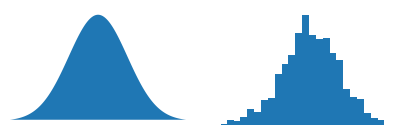

In [4]:
np.random.seed(seed=1)
x = np.linspace(-3, 3, 300)
xsample = stats.norm.rvs(size=1000)

fig, axes = plt.subplots(ncols=2, figsize=(5, 1.5))

ax = axes[0]
ax.fill(x, stats.norm.pdf(x))
ax.set_axis_off()
ax.set_xlim(-3, 3)

ax = axes[1]
ax.hist(xsample, bins=30)
ax.set_axis_off()
ax.set_xlim(-3, 3)
ax.set_position
# plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)

plt.show()

# Sampling Distribution of a Statistic

In [9]:
 loans_income.sample(1000)

,x
33798,89000
36591,80000
36202,37500
37792,56000
32112,156000
...,...
31639,40000
31295,100000
27450,57712
33796,30000


In [18]:
pd.DataFrame({"income": loans_income.sample(1000)['x'], 'type': ['Data'] * 1000})

,income,type
26000,45000,Data
10312,128000,Data
4643,60000,Data
43107,37000,Data
28153,50000,Data
...,...,...
2489,64500,Data
23207,33200,Data
24720,76000,Data
29345,60000,Data


In [19]:
pd.DataFrame(
    {
        'income': loans_income.sample(1000)['x'], 'type': ['Data'] * 1000})

,income,type
34014,39000,Data
4021,30840,Data
15144,72000,Data
37376,14400,Data
17504,45000,Data
...,...,...
49221,72800,Data
49014,54000,Data
8762,31000,Data
11991,39000,Data


In [21]:
loans_income = pd.read_csv("/content/loans_income.csv")

sample_data = pd.DataFrame({
    'income': loans_income.sample(1000)['x'], 'type': ['Data'] * 1000})

sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5)['x'].mean() for _ in range(1000)],
    'type': ['Mean of 5'] * 1000,
})

sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20)['x'].mean() for _ in range(1000)],
    'type': ['Mean of 20'] * 1000,
})

results = pd.concat([sample_data, sample_mean_05, sample_mean_20])
print(results.head())

        income  type
2571   57000.0  Data
12066  75000.0  Data
767    42500.0  Data
14238  49000.0  Data
23651  79000.0  Data


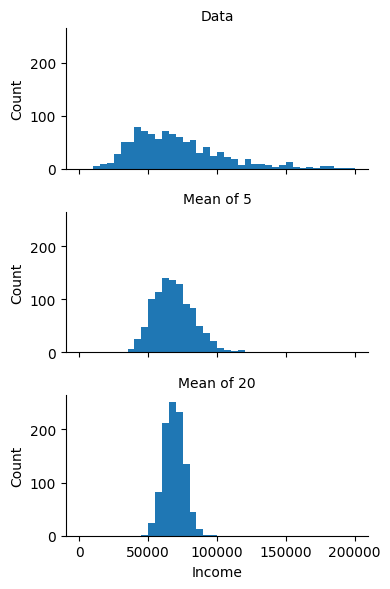

In [23]:
g = sns.FacetGrid(results, col='type', col_wrap=1,
                  height=2, aspect=2)
g.map(plt.hist, 'income', range=[0, 200000], bins=40)
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')

plt.tight_layout()
plt.show()

# The Bootstrap

In [24]:
results = []
for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)
print('Bootstrap Statistics:')
print(f'original: {loans_income.median()}')
print(f'bias: {results.mean() - loans_income.median()}')
print(f'std. error: {results.std()}')

Bootstrap Statistics:
original: x    62000.0
dtype: float64
bias: x   -81.3855
dtype: float64


/tmp/ipykernel_18354/2424068891.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f'bias: {results.mean() - loans_income.median()}')
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


TypeError: Could not convert [x    1839.16611
 dtype: float64  x    6623.59961
                 dtype: float64  x    6623.59961
                                 dtype: float64  x    6623.59961
                                                 dtype: float64
 x    6623.59961
 dtype: float64  x    6623.59961
                 dtype: float64  x    6623.59961
                                 dtype: float64  x    6623.59961
                                                 dtype: float64
 x    6623.59961
 dtype: float64  x    6623.59961
                 dtype: float64  x    6623.59961
                                 dtype: float64  x    190632.22161
                                                 dtype: float64
 x    175238.09961
 dtype: float64    x    6623.59961
                   dtype: float64  x    6623.59961
                                   dtype: float64  x    6623.59961
                                                   dtype: float64
 x    6623.59961
 dtype: float64  x    92181.76

# Confidence Intervals

In [25]:
print(loans_income.mean())
np.random.seed(seed=3)
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)
print(sample20.mean())
results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [55, 55], color='black')
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color='black')
    ax.text(x, 70, f'{x:.0f}',
            horizontalalignment='center', verticalalignment='center')
ax.text(sum(confidence_interval) / 2, 60, '90% interval',
        horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 10, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

x    68760.51844
dtype: float64
x    55734.1
dtype: float64


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

Text(0, 0.5, 'Counts')

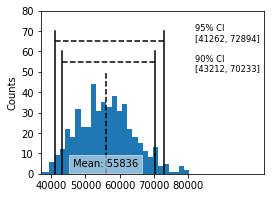

In [ ]:
np.random.seed(seed=3)
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)

results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3), color='C1')
ax.plot(confidence_interval, [55, 55], color='black', linestyle='--')
for x in confidence_interval:
    ax.plot([x, x], [0, 60], color='black')
ax.text(82000, 50,
        f'90% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]',
       fontsize='small')

confidence_interval = list(results.quantile([0.025, 0.975]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [65, 65], color='black', linestyle='--')
for x in confidence_interval:
    ax.plot([x, x], [0, 70], color='black')
ax.text(82000, 65,
        f'95% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]',
       fontsize='small')
# ax.text(sum(confidence_interval) / 2, 264, '95 % interval',
#         horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 5, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_xlim(37000, 102000)
ax.set_xticks([40000, 50000, 60000, 70000, 80000])
ax.set_ylabel('Counts')

# plt.tight_layout()
# plt.show()

# Normal Distribution
## Standard Normal and QQ-Plots
The package _scipy_ has the function (`scipy.stats.probplot`) to create QQ-plots. The argument `dist` specifies the distribution, which is set by default to the normal distribution.

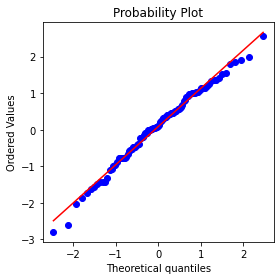

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))

norm_sample = stats.norm.rvs(size=100)
stats.probplot(norm_sample, plot=ax)

plt.tight_layout()
plt.show()

# Long-Tailed Distributions

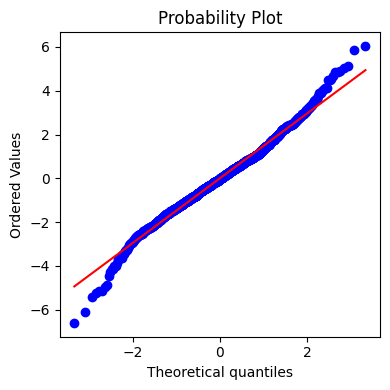

In [27]:
# Imports necessary for this cell
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pylab as plt

# Define DATA path (from D21K24uX_SjO, ensuring it's available for this cell)
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

# Define SP500_DATA_CSV path (from Macpfd2k_SjO, ensuring it's available for this cell)
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'

try:
    sp500_px = pd.read_csv("/content/sp500_data.csv.gz")

    nflx = sp500_px.NFLX
    nflx = np.diff(np.log(nflx[nflx>0]))

    fig, ax = plt.subplots(figsize=(4, 4))
    stats.probplot(nflx, plot=ax)

    plt.tight_layout()
    plt.show()
except EOFError:
    print("An EOFError occurred while reading the compressed CSV file.")
    print("This usually means the file 'sp500_data.csv.gz' is corrupted or incomplete.")
    print("Please verify the integrity of your data file.")
    raise # Re-raise the error to stop execution as the file itself needs fixing.
except FileNotFoundError:
    print(f"Error: The file '{SP500_DATA_CSV}' was not found.")
    print("Please ensure the data file is present at the specified path.")
    raise
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    raise


# Binomial Distribution

In [28]:
print(stats.binom.pmf(2, n=5, p=0.1))

0.07289999999999992


In [29]:
print(stats.binom.cdf(2, n=5, p=0.1))

0.99144


# Poisson and Related Distribution
## Poisson Distributions

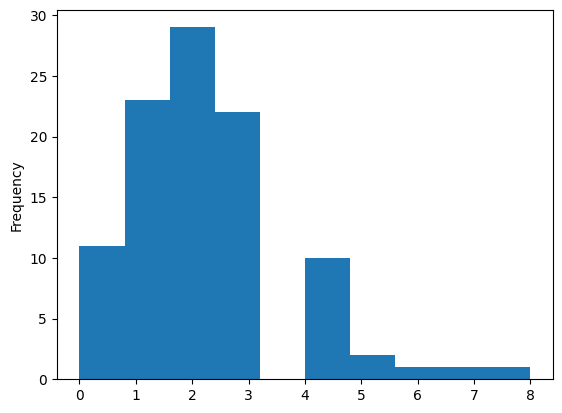

In [30]:
sample = stats.poisson.rvs(2, size=100)

pd.Series(sample).plot.hist()
plt.show()

## Exponential Distribution

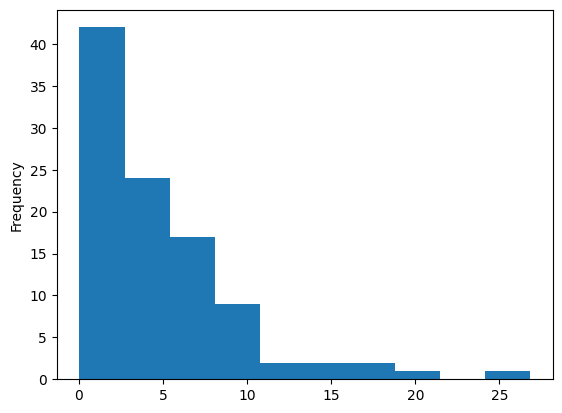

In [31]:
sample = stats.expon.rvs(scale=5, size=100)

pd.Series(sample).plot.hist()
plt.show()

##  Weibull Distribution

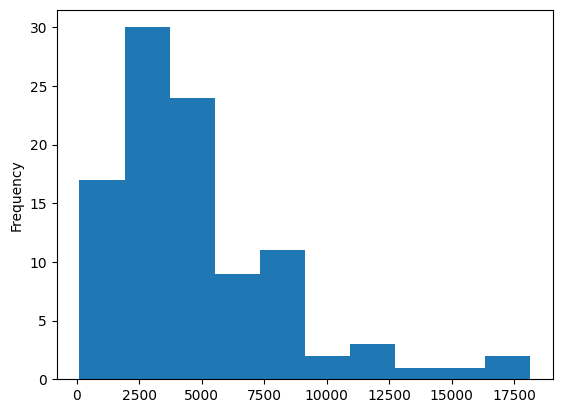

In [32]:
sample = stats.weibull_min.rvs(1.5, scale=5000, size=100)

pd.Series(sample).plot.hist()
plt.show()